# Lab 3: Causal Price Elasticity Estimation

## The Research Question

How does a change in price affect the quantity sold? This is the central question of demand analysis. It sounds simple, but answering it from observational data is difficult because prices and quantities are jointly determined. Products that sell more tend to have higher visibility, attract more reviews, and may command higher prices. At the same time, sellers often discount products that are not selling well. Both mechanisms create a correlation between price and quantity that does not reflect the causal effect of price on demand.

## The Causal Model

We work with the following structural equation model (SEM).

**Assumption 1 (SEM).** At each period $t$, the data are generated by
$$Q_{it} = a_t(S_{it}, \epsilon_{it})\,P_{it} + q_t(S_{it}, \epsilon_{it}),$$
$$P_{it} = p_t(S_{it}, \epsilon^p_{it}),$$
$$S_{it} = s_t(S_{i,t-1}, \epsilon^s_{it}),$$
where $a_t, q_t, p_t, s_t$ are nonparametric structural functions and $\epsilon_{it}, \epsilon^p_{it}, \epsilon^s_{it}$ are mutually independent i.i.d. stochastic vectors. The state vector $S_{it} = (Q_{i,t-1}, P_{i,t-1}, X_{it})$ contains lagged outcomes and product characteristics $X_{it}$.

**Causal parameters.** The elasticity (price sensitivity) is $A_{it} := a_t(S_{it}, \epsilon_{it})$. It can vary across products and over time. The potential outcome of product $i$ in period $t$ at price $p$ is
$$Q_{it}(p) = A_{it} \cdot p + q_t(S_{it}, \epsilon_{it}).$$

The conditional average causal effect (CACE) is the expected marginal effect of price given the current state:
$$\alpha_t(S_{it}) = E[A_{it} \mid S_{it}] = E\!\left[\frac{\partial Q_{it}(p)}{\partial p} \,\Big|\, S_{it}\right].$$
The average causal effect (ACE) integrates over the state distribution:
$$\alpha_t = E[A_{it}].$$
In this notebook we estimate the ACE, treating the effect as homogeneous. Heterogeneous effects are left for future labs.

## Estimation via Double Machine Learning

The **partially linear regression (PLR)** model,
$$Q_{it} = \delta_t \cdot P_{it} + \gamma_t(S_{it}) + u_{it}, \qquad E[u_{it} \mid S_{it}, P_{it}^\perp] = 0,$$
where $\gamma_t(S_{it}) := E[q_t(S_{it}, \epsilon_{it}) \mid S_{it}]$ is a flexible control function that absorbs the confounding variation. The coefficient $\delta_t$ identifies the ACE $\alpha_t$.

We estimate the PLR using the **double machine learning (DML)** approach of Chernozhukov et al. (2018). The idea is to partial out the state from both $Q_{it}$ and $P_{it}$ using machine learning, and then regress the outcome residual on the treatment residual:
$$Q_{it}^\perp = \delta_t \cdot P_{it}^\perp + e_{it}.$$

The resulting estimator is
$$\hat{\delta}_t = \frac{\sum_i \hat{P}_{it}^\perp \hat{Q}_{it}^\perp}{\sum_i (\hat{P}_{it}^\perp)^2}.$$

**Remark (Neyman orthogonality).** The DML estimator is Neyman orthogonal: perturbations in the nuisance functions $E[Q_{it} \mid S_{it}]$ and $E[P_{it} \mid S_{it}]$ have no first-order effect on $\hat{\delta}_t$. This means the estimator is robust to moderate errors in the machine learning predictions. It also implies that using estimated (fine-tuned) embeddings rather than ideal ones does not invalidate inference, provided the embeddings are estimated from an independent sample.

In [ ]:
%pip install doubleml

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 603.5/603.5 kB 13.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.7/14.7 MB 54.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 16.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 230.3/230.3 kB 10.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.3/57.3 kB 3.8 MB/s eta 0:00:00


In [ ]:
import re
import datasets
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from doubleml import DoubleMLData, DoubleMLPLR
from lightgbm import LGBMRegressor
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.preprocessing import normalize
from sklearn.metrics import pairwise_distances, r2_score

palette = sns.color_palette("colorblind")
confidence_level = 0.90
# Filter by the specific message substring
warnings.filterwarnings("ignore", message="X does not have valid feature names")

## 1. Load Data

In [ ]:
df_train = pd.read_csv(r"https://github.com/JanTeichertKluge/demand-analysis-repro/raw/refs/heads/main/main/data/dataset_txt_only_False_embeddings_True_train.zip")
df_test = pd.read_csv(r"https://github.com/JanTeichertKluge/demand-analysis-repro/raw/refs/heads/main/main/data/dataset_txt_only_False_embeddings_True_val.zip")

ds = datasets.DatasetDict()
ds["train"] = datasets.Dataset.from_pandas(df_train)
ds["test"] = datasets.Dataset.from_pandas(df_test)

print(f"Train: {df_train.shape}  |  Test: {df_test.shape}")

Train: (41945, 348)  |  Test: (41832, 348)


## 2. Check Embedding Features

In [ ]:
pca_cols = [f"pca_{i}" for i in range(5)]
sim_cols = [f"similarity_cluster_{i}" for i in range(5)]

print(f"PCA columns: {pca_cols}")
print(df_test[pca_cols].head())
print(f"Similarity columns: {sim_cols}")
print(df_test[sim_cols].head())

PCA columns: ['pca_0', 'pca_1', 'pca_2', 'pca_3', 'pca_4']
      pca_0     pca_1     pca_2     pca_3     pca_4
0  0.048269 -0.726435 -0.025251  0.170686  0.070860
1  0.048269 -0.726435 -0.025251  0.170686  0.070860
2  0.048269 -0.726435 -0.025251  0.170686  0.070860
3  0.044607 -0.726271 -0.032725  0.165358  0.071115
4  0.044607 -0.726271 -0.032725  0.165358  0.071115
Similarity columns: ['similarity_cluster_0', 'similarity_cluster_1', 'similarity_cluster_2', 'similarity_cluster_3', 'similarity_cluster_4']
   similarity_cluster_0  similarity_cluster_1  similarity_cluster_2  \
0             -0.427115              0.448444              0.475884   
1             -0.427115              0.448444              0.475884   
2             -0.427115              0.448444              0.475884   
3             -0.426929              0.444972              0.476248   
4             -0.426929              0.444972              0.476248   

   similarity_cluster_3  similarity_cluster_4  
0            

## 3. Check Lagged Variables and Dummies

In [ ]:
subcat_cols = [
 'Airplanes.1',
 'Cars & Race Cars.1',
 'Motor Vehicles.1',
 'Race Tracks.1',
 'Residual.1',
 'Skateboards.1',
 'Tractors.1',
 'Train Sets.1',
 'Trains & Trams.1',
 'Trucks.1',
 'Vehicle Playsets.1',
]

time_cols = [
 '2023-01-30',
 '2023-02-27',
 '2023-03-27',
 '2023-04-24',
 '2023-05-22',
 '2023-06-19',
 '2023-07-17',
 '2023-08-14',
 '2023-09-11',
 '2023-10-09',
 '2023-11-06',
 '2023-12-04',
 '2024-01-01',
 '2024-01-29',
]

print(df_test[subcat_cols].head())
print(df_test[time_cols].head())

df_train = df_train.dropna(subset=["Q_t-1", "P_bb_t-1"]).reset_index(drop=True)
df_test  = df_test.dropna(subset=["Q_t-1", "P_bb_t-1"]).reset_index(drop=True)

print(f"After lag construction  ->  Train: {df_train.shape}  |  Test: {df_test.shape}")

   Airplanes.1  Cars & Race Cars.1  Motor Vehicles.1  Race Tracks.1  \
0            0                   0                 0              0   
1            0                   0                 0              0   
2            0                   0                 0              0   
3            0                   0                 0              0   
4            0                   0                 0              0   

   Residual.1  Skateboards.1  Tractors.1  Train Sets.1  Trains & Trams.1  \
0           1              0           0             0                 0   
1           1              0           0             0                 0   
2           1              0           0             0                 0   
3           1              0           0             0                 0   
4           1              0           0             0                 0   

   Trucks.1  Vehicle Playsets.1  
0         0                   0  
1         0                   0  
2         0   

## 4. Define Control Specifications

We compare five control specifications to assess robustness. The key question is whether the estimated elasticity changes materially when we enrich the control function $\gamma_t(S_{it})$. If the estimate is stable across specifications, we have more confidence that the controls successfully absorb the confounding.

In [ ]:
outcome   = "Q_t"
treatment = "P_bb_t"

lag_controls = ["Q_t-1", "P_bb_t-1"]
tabular_candidates = [
    "RATING_t-1", "REVIEW_COUNT_t-1",
    "New Offer Count: Current",
    "Count of retrieved live offers: New, FBA",
    "Count of retrieved live offers: New, FBM",
    "Lightning Deals: Upcoming Deal",
    "Buy Box: Is FBA",
]
tabular_controls = [c for c in tabular_candidates if c in df_train.columns]
base_controls    = lag_controls + tabular_controls + subcat_cols + time_cols

control_specs = {
    "Lagged vars only":    lag_controls,
    "Tabular controls":    base_controls,
    "Tabular + PCA":       base_controls + pca_cols,
    "Tabular + Sim":       base_controls + sim_cols,
}

In [ ]:
for lbl, spcs in control_specs.items():
  print(lbl, spcs, "\n")

Lagged vars only ['Q_t-1', 'P_bb_t-1'] 

Tabular controls ['Q_t-1', 'P_bb_t-1', 'RATING_t-1', 'REVIEW_COUNT_t-1', 'New Offer Count: Current', 'Count of retrieved live offers: New, FBA', 'Count of retrieved live offers: New, FBM', 'Lightning Deals: Upcoming Deal', 'Buy Box: Is FBA', 'Airplanes.1', 'Cars & Race Cars.1', 'Motor Vehicles.1', 'Race Tracks.1', 'Residual.1', 'Skateboards.1', 'Tractors.1', 'Train Sets.1', 'Trains & Trams.1', 'Trucks.1', 'Vehicle Playsets.1', '2023-01-30', '2023-02-27', '2023-03-27', '2023-04-24', '2023-05-22', '2023-06-19', '2023-07-17', '2023-08-14', '2023-09-11', '2023-10-09', '2023-11-06', '2023-12-04', '2024-01-01', '2024-01-29'] 

Tabular + PCA ['Q_t-1', 'P_bb_t-1', 'RATING_t-1', 'REVIEW_COUNT_t-1', 'New Offer Count: Current', 'Count of retrieved live offers: New, FBA', 'Count of retrieved live offers: New, FBM', 'Lightning Deals: Upcoming Deal', 'Buy Box: Is FBA', 'Airplanes.1', 'Cars & Race Cars.1', 'Motor Vehicles.1', 'Race Tracks.1', 'Residual.1', 'Sk

## Linear Models

In [ ]:
def lin_model(df, treatments, controls=None,
              outcome="Q_t", level=0.90,
              cov_type="HC0", **kwargs):
    """Plain OLS: regress outcome on [treatments + controls];
    return a small summary DataFrame for the treatment rows."""
    alpha = 1 - level
    cols = list(treatments) + (list(controls) if controls else [])
    X = sm.add_constant(df[cols])
    y = df[outcome]

    res = sm.OLS(y, X).fit(cov_type=cov_type, **kwargs)
    ci = res.conf_int(alpha=alpha)

    out = pd.DataFrame({
        "coef":    res.params,
        "std_err": res.bse,
        "p":       res.pvalues,
        "lower":   ci[0],
        "upper":   ci[1],
    }).loc[list(treatments)]
    out["rsq_adj"] = res.rsquared_adj
    return out

In [ ]:
results_lin = []
for label, controls in control_specs.items():
    available = [c for c in controls if c in df_test.columns]
    df = df_test.dropna(subset=available + [treatment, outcome, "ASIN"]).copy()

    out = lin_model(
        df,
        treatments=[treatment],
        controls=available,
        outcome=outcome,
        level=confidence_level,
        cov_type="cluster",
        cov_kwds={"groups": df["ASIN"].values},
    )
    row = out.loc[treatment]
    results_lin.append({
        "label":  label,
        "delta":  row["coef"],
        "se":     row["std_err"],
        "ci_lo":  row["lower"],
        "ci_hi":  row["upper"],
        "pval":   row["p"],
        "r2_adj": row["rsq_adj"],
    })
    print(f"{label:30s}  delta={row['coef']:+.4f}  "
          f"[{row['lower']:+.4f}, {row['upper']:+.4f}]  "
          f"R2_adj={row['rsq_adj']:.3f}")

df_lin = pd.DataFrame(results_lin).set_index("label")

Lagged vars only                delta=-0.6936  [-0.7595, -0.6277]  R2_adj=0.883
Tabular controls                delta=-0.7491  [-0.8139, -0.6843]  R2_adj=0.893
Tabular + PCA                   delta=-0.7261  [-0.7895, -0.6626]  R2_adj=0.896
Tabular + Sim                   delta=-0.7248  [-0.7883, -0.6614]  R2_adj=0.896


## 5. DML Estimator

The function below implements the two-step DML procedure:

1. Train LightGBM models for $E[Q_{it} \mid S_{it}]$ and $E[P_{it} \mid S_{it}]$ on the training set.
2. Compute residuals on the test set: $\hat{Q}_{it}^\perp = Q_{it} - \hat{\gamma}^Q(S_{it})$ and $\hat{P}_{it}^\perp = P_{it} - \hat{\gamma}^P(S_{it})$.
3. Regress $\hat{Q}_{it}^\perp$ on $\hat{P}_{it}^\perp$ using OLS with standard errors clustered by product (ASIN) to obtain $\hat{\delta}_t$.

Clustering is important because we have multiple observations per product and the variance formula $V = E[(P^\perp_{it})^2]^{-2}\,E[(P^\perp_{it})^2\,e^2_{it}]$ requires accounting for the resulting within-product correlation.

In [ ]:
from sklearn.metrics import r2_score

def safe_r2_score(y_true, y_pred):
    # only evaluate on finite preds
    mask = np.isfinite(y_pred)
    return r2_score(y_true[mask], y_pred[mask])


def dml_plr(df_test, controls, outcome, treatment,
            confidence_level=0.90, label=""):
    """
    Partially linear regression via DoubleML with cluster-aware k-fold
    cross-fitting. Clusters are ASINs (multiple periods per product).
    """
    # DoubleML handles sample splitting internally
    # cluster_cols="ASIN" keeps all rows of an ASIN in the same fold

    # LightGBM rejects column names with special chars; sanitize consistently.
    available = [c for c in controls if c in df_test.columns]
    rename = {c: re.sub(r"[^A-Za-z0-9_]+", "", c) for c in available}
    df_test = df_test.rename(columns=rename)
    x_cols = list(rename.values())
    df_test[x_cols] = df_test[x_cols].dropna()

    # 1) DoubleMLData with cluster structure
    dml_data = DoubleMLData(
        df_test,
        y_col=outcome,
        d_cols=treatment,
        x_cols=x_cols,
        cluster_cols="ASIN",
    )

    # 2) Nuisance learners
    ml_l = LGBMRegressor(n_estimators=500, learning_rate=0.02,
                         random_state=42, verbose=-1)
    ml_m = LGBMRegressor(n_estimators=500, learning_rate=0.02,
                         random_state=42, verbose=-1)

    # 3) Fit PLR with partialling-out score
    dml_obj = DoubleMLPLR(
        dml_data,
        ml_l=ml_l,
        ml_m=ml_m,
        score="partialling out",
        n_folds=3,
    )
    dml_obj.fit(store_predictions=True)
    # print(dml_obj.summary)

    # 4) Residuals
    y = df_test[outcome].values
    d = df_test[treatment].values
    Q_perp = y - dml_obj.predictions["ml_l"][:, 0, 0]
    P_perp = d - dml_obj.predictions["ml_m"][:, 0, 0]

    # 5) Inference
    ci = dml_obj.confint(level=confidence_level)            # DataFrame
    eval_ = dml_obj.evaluate_learners(metric=safe_r2_score)
    r2_l = float(np.mean(eval_["ml_l"]))
    r2_m = float(np.mean(eval_["ml_m"]))

    return dict(
        label  = label,
        delta  = float(dml_obj.coef[0]),
        se     = float(dml_obj.se[0]),
        ci_lo  = float(ci.iloc[0, 0]),
        ci_hi  = float(ci.iloc[0, 1]),
        pval   = float(dml_obj.pval[0]),
        r2_l   = r2_l,
        r2_m   = r2_m,
        Q_perp = Q_perp,
        P_perp = P_perp,
    )

## 6. Estimate the Average Causal Effect

In [ ]:
results = []
for label, controls in control_specs.items():
    res = dml_plr(
        df_test,
        controls=controls,
        outcome=outcome,
        treatment=treatment,
        confidence_level=confidence_level,
        label=label,
    )
    results.append(res)
    lo, hi = res["ci_lo"], res["ci_hi"]
    print(f"{label:30s}  delta={res['delta']:+.4f}  "
          f"[{lo:+.4f}, {hi:+.4f}]  "
          f"R2_l={res['r2_l']:.3f}  R2_m={res['r2_m']:.3f}")

df_res = pd.DataFrame(
    [{k: v for k, v in r.items() if k not in ("Q_perp", "P_perp")} for r in results]
).set_index("label")

Lagged vars only                delta=-0.5896  [-0.6660, -0.5133]  R2_l=0.879  R2_m=0.974
Tabular controls                delta=-0.6436  [-0.7397, -0.5475]  R2_l=0.899  R2_m=0.976
Tabular + PCA                   delta=-0.6027  [-0.7115, -0.4938]  R2_l=0.901  R2_m=0.974
Tabular + Sim                   delta=-0.6417  [-0.7177, -0.5656]  R2_l=0.902  R2_m=0.977


## 7. Results Table

The table below reports the estimated ACE ($\hat{\delta}_t$), its standard error, and the 90% confidence interval for each specification, along with the test-set $R^2$ of the nuisance models.

In [ ]:
alpha = 1 - confidence_level
df_display = df_res[["delta", "se", "ci_lo", "ci_hi", "pval", "r2_l", "r2_m"]].copy()
df_display.columns = [
    "$\\hat{\\delta}_t$", "SE",
    f"{alpha/2*100:.0f}%", f"{(1-alpha/2)*100:.0f}%",
    "p-value", "R2 outcome", "R2 treatment"
]
df_display.index.name = "Controls"

In [ ]:
alpha = 1 - confidence_level

def _block(df, name):
    out = df[["delta", "se", "ci_lo", "ci_hi", "pval"]].copy()
    out.columns = [
        "$\\hat{\\delta}$", "SE",
        f"{alpha/2*100:.0f}%", f"{(1-alpha/2)*100:.0f}%",
        "p-value",
    ]
    return pd.concat({name: out}, axis=1)

df_compare = pd.concat(
    [_block(df_lin, "Linear (OLS)"),
     _block(df_res, "DML (LightGBM)")],
    axis=1,
)
df_compare.index.name = "Controls"
df_compare.round(4)

Linear (OLS)                                  \
                 $\hat{\delta}$      SE      5%     95% p-value   
Controls                                                          
Lagged vars only        -0.6936  0.0401 -0.7595 -0.6277     0.0   
Tabular controls        -0.7491  0.0394 -0.8139 -0.6843     0.0   
Tabular + PCA           -0.7261  0.0386 -0.7895 -0.6626     0.0   
Tabular + Sim           -0.7248  0.0386 -0.7883 -0.6614     0.0   

                 DML (LightGBM)                                  
                 $\hat{\delta}$      SE      5%     95% p-value  
Controls                                                         
Lagged vars only        -0.5896  0.0464 -0.6660 -0.5133     0.0  
Tabular controls        -0.6436  0.0584 -0.7397 -0.5475     0.0  
Tabular + PCA           -0.6027  0.0662 -0.7115 -0.4938     0.0  
Tabular + Sim           -0.6417  0.0462 -0.7177 -0.5656     0.0

## 8. Plot

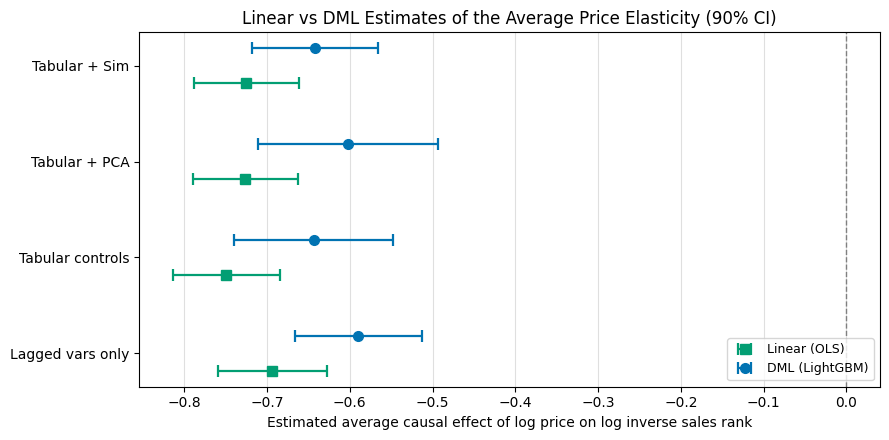

In [ ]:
fig, ax = plt.subplots(figsize=(9, 4.5))
labels = list(df_res.index)
y      = np.arange(len(labels))
offset = 0.18

# Linear (OLS)
ax.errorbar(
    x=df_lin["delta"].values, y=y - offset,
    xerr=[df_lin["delta"].values - df_lin["ci_lo"].values,
          df_lin["ci_hi"].values - df_lin["delta"].values],
    fmt="s", color=palette[2], ecolor=palette[2],
    capsize=4, capthick=1.6, lw=1.6, ms=7,
    label="Linear (OLS)",
)
# DML (LightGBM)
ax.errorbar(
    x=df_res["delta"].values, y=y + offset,
    xerr=[df_res["delta"].values - df_res["ci_lo"].values,
          df_res["ci_hi"].values - df_res["delta"].values],
    fmt="o", color=palette[0], ecolor=palette[0],
    capsize=4, capthick=1.6, lw=1.6, ms=7,
    label="DML (LightGBM)",
)
ax.axvline(0, color="gray", ls="--", lw=1)
ax.set_yticks(y)
ax.set_yticklabels(labels, fontsize=10)
ax.set_xlabel("Estimated average causal effect of log price on log inverse sales rank",
              fontsize=10)
ax.set_title(f"Linear vs DML Estimates of the Average Price Elasticity "
             f"({confidence_level*100:.0f}% CI)", fontsize=12)
ax.legend(loc="lower right", fontsize=9)
ax.grid(axis="x", alpha=0.4)
plt.tight_layout()
plt.show()

## 9. Diagnostics

To build intuition, we inspect the partialled-out residuals and the second-stage regression for the preferred specification (tabular controls plus cluster similarities).

The scatter plot on the right shows that after removing variation explained by the state, there is a clear negative relationship between the price residual and the quantity residual. This is the signal the DML estimator uses to recover the causal effect.

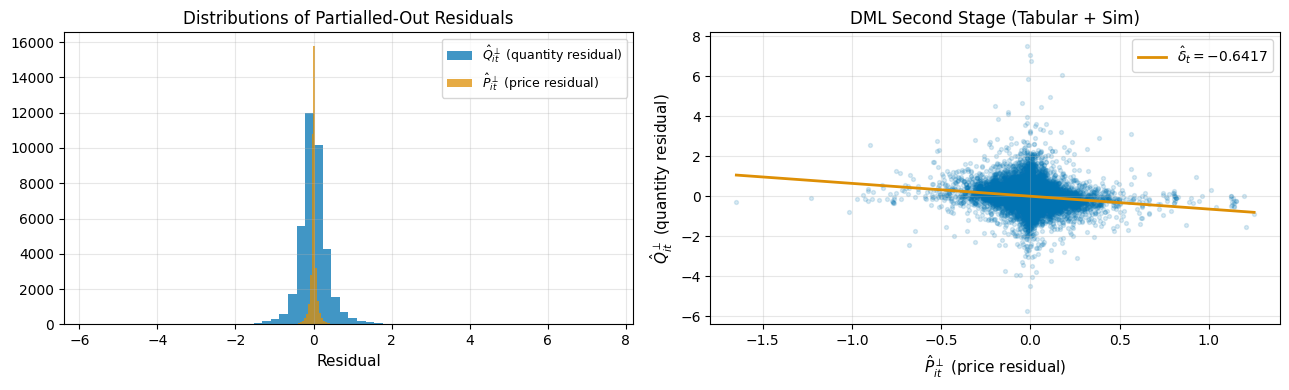

In [ ]:
preferred_label = "Tabular + Sim"
preferred = next(r for r in results if r["label"] == preferred_label)
Q_perp    = preferred["Q_perp"]
P_perp    = preferred["P_perp"]
delta_hat = preferred["delta"]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Distribution of residuals
axes[0].hist(Q_perp, bins=60, color=palette[0], alpha=0.75, edgecolor="none",
             label="$\\hat{Q}_{it}^\\perp$ (quantity residual)")
axes[0].hist(P_perp, bins=60, color=palette[1], alpha=0.75, edgecolor="none",
             label="$\\hat{P}_{it}^\\perp$ (price residual)")
axes[0].set_xlabel("Residual", fontsize=11)
axes[0].set_title("Distributions of Partialled-Out Residuals")
axes[0].legend(fontsize=9)
axes[0].grid(alpha=0.3)

# Second-stage scatter
axes[1].scatter(P_perp, Q_perp, alpha=0.15, s=8, color=palette[0])
p_grid = np.linspace(P_perp.min(), P_perp.max(), 100)
axes[1].plot(p_grid, delta_hat * p_grid, color=palette[1], lw=2,
             label=f"$\\hat{{\\delta}}_t = {delta_hat:.4f}$")
axes[1].set_xlabel("$\\hat{P}_{it}^\\perp$ (price residual)", fontsize=11)
axes[1].set_ylabel("$\\hat{Q}_{it}^\\perp$ (quantity residual)", fontsize=11)
axes[1].set_title("DML Second Stage (Tabular + Sim)")
axes[1].legend(fontsize=10)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Discussion

The estimated average causal effect is negative across all specifications, which is the expected sign: higher prices reduce the quantity sold. Because both $Q_{it}$ and $P_{it}$ are in logs, the coefficient $\hat{\delta}_t$ has an approximate elasticity interpretation. A value of $\hat{\delta}_t \approx -0.7$ means that a one percent increase in the buy-box price reduces the inverse sales rank by about 0.7 percent.

Note that the inverse sales rank is itself a transformation of demand. Under a Pareto distribution with shape parameter $\vartheta$ for units sold, the price sensitivity of actual demand is approximately $1/\vartheta$ times the rank elasticity. With the assumed $\hat{\vartheta} \approx 0.5$ for toys on Amazon, multiplying our rank elasticity estimates by $1/\hat{\vartheta} \approx 2$ gives approximate demand elasticities. With $\hat{\delta}_t \approx -0.7$, the implied demand elasticity is approximately $-1.4$, which is economically plausible for consumer goods.

Two features of the results are reassuring. First, the estimates are stable across control specifications. Adding PCA or similarity controls does not change the estimate much, suggesting that the lagged variables already absorb most of the relevant confounding. Second, the confidence intervals are tight and do not include zero in any specification, so we can rule out a zero price effect with high confidence.
